# Import Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import dates as md
import time
import re, fileinput, sys, pathlib, os
from itertools import cycle
import numpy as np

In [2]:
def parsefile(file):
    throughput_pattern = re.compile(r'\[OVERALL\], Throughput\(ops/sec\), (\d+.?\d*)')
    read_num_pattern = re.compile(r'\[READ\], Total Operations, (\d+)')
    read_ok_pattern = re.compile(r'\[READ\], Return=OK, (\d+)')
    read_pattern = re.compile(r'\[READ\], ([A-Za-z]+|p\d+\.?\d*), (\d+)')
    update_pattern = re.compile(r'\[UPDATE\], ([A-Za-z]+|p\d+\.?\d*), (\d+)')
    update_num_pattern = re.compile(r'\[UPDATE\], Total Operations, (\d+)')
    update_ok_pattern = re.compile(r'\[UPDATE\], Return=OK, (\d+)')
    runtimep = re.compile(r'\[OVERALL\], RunTime\(ms\), (\d+)')
    throughput = 'not_found'
    read_num = 'not_found'
    read_ok = 'not_found'
    read = {}
    update_num = 'not_found'
    update_ok = 'not_found'
    update = {}

    result = {}
    
    with open(file) as f:
        for line in f:
            m = runtimep.search(line)
            if m:
                result = result | {'runtime(ms)': m.group(1)}
            m = throughput_pattern.search(line)
            if m:
                throughput = m.group(1)
            m = read_num_pattern.search(line)
            if m:
                read_num = m.group(1)
            m = read_ok_pattern.search(line)
            if m:
                read_ok = m.group(1)
            m = read_pattern.search(line)
            if m:
                label = f'read_{m.group(1).lower()}(us)'
                read = read | {label: m.group(2)}
            m = update_num_pattern.search(line)
            if m:
                update_num = m.group(1)
            m = update_ok_pattern.search(line)
            if m:
                update_ok = m.group(1)
            m = update_pattern.search(line)
            if m:
                label = f'update_{m.group(1).lower()}(us)'
                update = update | {label: m.group(2)}
    return result | {'throughput(ops/s)': [throughput], 'read_num': [read_num], 'read_ok': [read_ok], 'update_num': [update_num], 'update_ok': [update_ok]} | read | update

In [3]:
df = pd.DataFrame()
workloadp = re.compile(r'workload[a-z]|writeonly|readonly')
nodesp = re.compile(r'(\d+)nodes')
threadsp = re.compile(r'(\d+)threads')
targetp = re.compile(r'([0-9a-z]+)target')
operationsp = re.compile(r'(\d+)operations')
recordsp = re.compile(r'(\d+)records')
timeoutp = re.compile(r'(\d+)timeout')
batchsizep = re.compile(r'(\d+)batchsize')
kill_leaderp = re.compile(r'(\d+)kill_leader')
timep = re.compile(r'\d+-\d+-\d+-\d+:\d+:\d+')
geo_replp = re.compile(r'geo-repl')
single_conp = re.compile(r'single-con')
historyp = re.compile(r'history([A-Za-z]+\d*)')
commitreadsp = re.compile(r'commitreads([A-Za-z]+)')
twconnp = re.compile(r'twoWayConnections')
smallrepp = re.compile(r'smallReplies')
futurep = re.compile(r'future')
atomicp = re.compile(r'atomic-refs')
testp = re.compile(r'simple-test')
for kind in ['pb', 'etcd']:
    for fileObj in os.scandir("../results/raw/"+kind):
        file = fileObj.name
        workload = workloadp.search(file).group()
        nodes = nodesp.search(file).group(1)
        threads = threadsp.search(file).group(1)
        target = targetp.search(file).group(1)
        time = timep.search(file).group(0)
        m = commitreadsp.search(file)
        if m:
            commitreads = m.group(1).lower()
        else:
            commitreads = 'undefined'
        m = operationsp.search(file)
        if m:
            operations = m.group(1)
        else:
            operations = 'undefined'
        m = recordsp.search(file)
        if m:
            records = m.group(1)
        else:
            records = 'undefined'
        m = timeoutp.search(file)
        if m:
            timeout = m.group(1)
        else:
            timeout = 'undefined'
        m = batchsizep.search(file)
        if m:
            batchsize = m.group(1)
        else:
            batchsize = 'undefined'
        m = kill_leaderp.search(file)
        if m:
            kill_leader = m.group(1)
        else:
            kill_leader = 'undefined'
        m = geo_replp.search(file)
        if m:
            geo_repl = True
        else:
            geo_repl = False
        m = single_conp.search(file)
        if m:
            single_con = True
        else:
            single_con = False
        m = historyp.search(file)
        if m:
            history = m.group(1).lower()
        else:
            history = 'undefined'
        m = twconnp.search(file)
        if m:
            twconn = True
        else:
            twconn = 'undefined'
        m = smallrepp.search(file)
        if m:
            smallrep = True
        else:
            smallrep = 'undefined'
        m = futurep.search(file)
        if m:
            future = True
        else:
            future = 'undefined'
        m = atomicp.search(file)
        if m:
            atomic = True
        else:
            atomic = 'undefined'
        m = testp.search(file)
        if m:
            test = True
        else:
            test = 'undefined'
    
        header_data = {'system': [kind], 'small_replies': [smallrep], 'simple_test': [test], 'future': [future], 'atomic_refs': [atomic], 'single_con': [single_con], 'tw_conn': [twconn], 'geo_repl': [geo_repl], 'time': [time], 'workload': [workload], 'nodes': [nodes], 'threads': [threads], 'target': [target], 'operations': [operations], 'records': [records], 'timeout': [timeout], 'batchsize': [batchsize], 'kill_leader': [kill_leader], 'history': [history], 'filename': [file], 'commit_reads': [commitreads]}
        in_file_data = parsefile(fileObj.path)
        new_row = pd.DataFrame(header_data | in_file_data)
        df = pd.concat([df,new_row])
    

In [4]:
# clean up df and change datatypes
df = df[df['throughput(ops/s)'] != 'not_found']
df['time'] = pd.to_datetime(df['time'])
df = df.astype({'nodes': 'int32', 'threads': 'int32', 'throughput(ops/s)': 'float64', 'update_p90(us)': 'Int64', 'update_p99(us)': 'Int64', 'update_average(us)': 'Int64', 'runtime(ms)': 'int64', 'timeout': 'int64'})
df['update_p99(ms)'] = df['update_p99(us)'] / 1000
df['update_p90(ms)'] = df['update_p90(us)'] / 1000
df['update_average(ms)'] = df['update_average(us)'] / 1000
df['runtime(s)'] = df['runtime(ms)'] / 1000
df = df.round({"runtime(s)": 0})
df['runtime(s)'] = df['runtime(s)'].astype(int)
#df['read_p99(ms)'] = df['read_p99(us)'] / 1000
df = df.reset_index()
df.drop('index', axis=1)

,system,small_replies,simple_test,future,atomic_refs,single_con,tw_conn,geo_repl,time,workload,...,read_p50(us),read_p90(us),read_p95(us),read_p99(us),read_p99.9(us),read_p99.99(us),update_p99(ms),update_p90(ms),update_average(ms),runtime(s)
0,pb,undefined,undefined,undefined,undefined,False,undefined,False,2026-07-23 15:04:42,writeonly,...,NaN,NaN,NaN,NaN,NaN,NaN,2.846,1.858,1.338,73
1,pb,undefined,undefined,undefined,undefined,False,undefined,False,2026-07-23 15:39:29,writeonly,...,NaN,NaN,NaN,NaN,NaN,NaN,2.16,1.042,0.788,46
2,pb,undefined,undefined,undefined,undefined,False,undefined,False,2026-07-23 15:41:15,writeonly,...,NaN,NaN,NaN,NaN,NaN,NaN,1.833,1.087,0.851,28
3,pb,undefined,undefined,undefined,undefined,False,undefined,False,2026-07-23 15:43:03,writeonly,...,NaN,NaN,NaN,NaN,NaN,NaN,2.747,1.45,1.124,24
4,pb,undefined,undefined,undefined,undefined,False,undefined,False,2026-07-23 15:44:53,writeonly,...,NaN,NaN,NaN,NaN,NaN,NaN,19.218,10.244,7.143,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,etcd,undefined,undefined,undefined,undefined,False,undefined,False,2026-07-23 20:00:32,workloadb,...,943,1055,1102,1402,2725,4662,4.168,3.222,2.678,104
57,etcd,undefined,undefined,undefined,undefined,False,undefined,False,2026-07-23 20:02:39,workloadb,...,802,1048,1313,2092,3155,5198,3.675,2.763,2.224,47
58,etcd,undefined,undefined,undefined,undefined,False,undefined,False,2026-07-23 20:05:11,workloadb,...,969,1321,1739,2449,4718,7207,3.798,2.779,2.22,37
59,etcd,undefined,undefined,undefined,undefined,False,undefined,False,2026-07-23 20:07:18,workloadb,...,1125,2135,2505,3433,6542,313436,4.425,3.036,2.268,15


# Geo-Replicated

## helper functions

In [5]:
def plot_dist_lat(ylim = None):
    axl = None
    colorcycler = cycle(['blue', 'orange', 'green', 'purple'])
    lines = ["dotted", 'solid']
    linestylecycler = cycle(lines)
    for system in ['etcd', 'pb']:
        linestyle=next(linestylecycler)
        for nodes in [3, 9]:
            color = next(colorcycler)
            # find relevant data
            relevant_data = df[(df['system'] == system) & (df['workload'] == 'writeonly') & (df['threads'].isin([1, 20, 50, 75, 100, 200])) & (df['geo_repl'] == True) & (df['nodes'] == nodes) & ~(df['update_p99(ms)'].isna()) & (df['kill_leader'] == 'undefined')]
            # last three entries per config
            plotdf = relevant_data.sort_values('time').groupby(['system', 'threads']).tail(3)
            plotdf = plotdf.groupby(['system', 'threads']).agg({'throughput(ops/s)': 'mean', 'update_average(ms)': 'mean', 'update_p99(ms)': 'mean'}).sort_values('threads').reset_index()
            #plotdf = relevant_data.sort_values('time').groupby(['system', 'threads']).tail(1).sort_values('threads')
            if system == 'pb':
                label = f'PRDT {nodes} nodes geo-replicated'
            else:
                label = f'{system} {nodes} nodes geo-replicated'
            if plotdf.size > 0:
                #print(plotdf[['nodes', 'threads', 'target', 'throughput(ops/s)']])
                if axl:
                    plotdf.plot(x='threads', y='update_p99(ms)', marker="x", color=color, linestyle=linestyle, label=label, ax=axl)
                else:
                    axl = plotdf.plot(x='threads', y='update_p99(ms)', marker="x", color=color, linestyle=linestyle, label=label)
                plt.ylabel('latency p99 (ms)')
                plt.xlabel('number of clients')
        if ylim:
            plt.ylim(ylim)
    plt.savefig(f'dist_lat.pdf', bbox_inches='tight')

def plot_dist_through(ylim = None):
    axt = None
    colorcycler = cycle(['blue', 'orange', 'green', 'purple'])
    lines = ["dotted", 'solid']
    linestylecycler = cycle(lines)
    colorcycler = cycle(['blue', 'orange', 'green', 'purple'])
    for system in ['etcd', 'pb']:
        linestyle=next(linestylecycler)
        for nodes in [3, 9]:
            color = next(colorcycler)
            # find relevant data
            relevant_data = df[(df['system'] == system) & (df['workload'] == 'writeonly') & (df['threads'].isin([1, 20, 50, 75, 100, 200])) & (df['nodes'] == nodes) & ~(df['update_p99(ms)'].isna()) & (df['kill_leader'] == 'undefined')]
            # last three entries per config
            plotdf = relevant_data.sort_values('time').groupby(['system', 'threads']).tail(3)
            plotdf = plotdf.groupby(['system', 'threads']).agg({'throughput(ops/s)': 'mean', 'update_average(ms)': 'mean', 'update_p99(ms)': 'mean'}).sort_values('threads').reset_index()
            if system == 'pb':
                label = f'PRDT {nodes} nodes geo-replicated'
            else:
                label = f'{system} {nodes} nodes geo-replicated'
            if plotdf.size > 0:
                #print(plotdf[['nodes', 'threads', 'target', 'throughput(ops/s)']])
                if axt:
                    plotdf.plot(x='threads', y='throughput(ops/s)', marker="x", color=color, linestyle=linestyle, label=label, ax=axt)
                else:
                    axt = plotdf.plot(x='threads', y='throughput(ops/s)', marker="x", color=color, linestyle=linestyle, label=label)
                plt.ylabel('throughput(ops/s)')
                plt.xlabel('number of clients')
        if ylim:
            plt.ylim(ylim)
    plt.savefig(f'dist_through.pdf', bbox_inches='tight')

## prepare dataset

In [6]:
filtered = df[(df['threads'].isin([1, 20, 50, 75, 100, 200])) & (df['workload'] == 'writeonly') & (df['geo_repl'] == True) & ((df['batchsize'] == '1') | (df['system'] == 'pb')) & ~(df['update_p99(ms)'].isna()) & (df['kill_leader'] == 'undefined')]
filtered = filtered.sort_values('time').groupby(['system', 'threads', 'nodes']).tail(3)
aggregated = filtered.groupby(['system', 'threads', 'nodes']).agg({'throughput(ops/s)': 'mean', 'update_average(ms)': 'mean', 'update_p99(ms)': 'mean',  'update_p90(ms)': ['mean', 'var'], 'runtime(s)': 'mean', 'workload': ['first', 'count'], 'time': ['first', 'last']}).sort_values(['nodes', 'threads', 'system']).reset_index()
#filtered[['system', 'threads', 'workload', 'throughput(ops/s)', 'update_p99(ms)', 'read_p99(ms)', 'time']]
etcdframe = aggregated[aggregated['system'] == 'etcd']
pbframe = aggregated[(aggregated['system'] == 'pb')]
joined = pbframe.merge(etcdframe, on=['threads', 'nodes'], suffixes=['_pb', '_etcd'])
joined[['threads', 'nodes','workload_pb', 'workload_etcd', 'throughput(ops/s)_pb', 'throughput(ops/s)_etcd', 'update_p99(ms)_pb', 'update_p99(ms)_etcd', 'time_pb', 'time_etcd']]

/tmp/ipykernel_367/1963175085.py:7: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  joined = pbframe.merge(etcdframe, on=['threads', 'nodes'], suffixes=['_pb', '_etcd'])


threads nodes workload_pb       workload_etcd       throughput(ops/s)_pb  \
                       first count         first count                 mean   
0        1     3   writeonly     1     writeonly     1             9.686919   
1       20     3   writeonly     1     writeonly     1             9.792018   
2       50     3   writeonly     1     writeonly     1             9.782056   
3       75     3   writeonly     1     writeonly     1             9.801039   
4      100     3   writeonly     1     writeonly     1             9.796622   
5      200     3   writeonly     1     writeonly     1             9.777847   
6        1     9   writeonly     1     writeonly     1             9.931177   
7       20     9   writeonly     1     writeonly     1             9.972377   
8       50     9   writeonly     1     writeonly     1            10.032606   
9       75     9   writeonly     1     writeonly     1            10.023957   
10     100     9   writeonly     1     writeonly     1             9.966811   
11     200     9   writeonly     1     writeonly     1             9.963236   

   throughput(ops/s)_etcd update_p99(ms)_pb update_p99(ms)_etcd  \
                     mean              mean                mean   
0                9.568096           105.749             106.897   
1              173.761946          2061.092             413.363   
2              338.294993          5149.133             500.061   
3              419.111484            7709.8             605.671   
4              473.933649         10255.417             665.171   
5              520.291363         20520.591             884.211   
6                9.799886           103.066             103.519   
7              170.794193          2041.977             404.111   
8              343.406593          5025.309               490.1   
9              415.973378          7537.885             604.181   
10             486.381323         10140.988             618.386   
11             541.125541         20201.556             835.432   

               time_pb                               time_etcd  \
                 first                last               first   
0  2026-07-23 17:01:42 2026-07-23 17:01:42 2026-07-23 17:22:35   
1  2026-07-23 17:05:05 2026-07-23 17:05:05 2026-07-23 17:25:24   
2  2026-07-23 17:08:33 2026-07-23 17:08:33 2026-07-23 17:28:07   
3  2026-07-23 17:11:57 2026-07-23 17:11:57 2026-07-23 17:31:01   
4  2026-07-23 17:15:23 2026-07-23 17:15:23 2026-07-23 17:33:29   
5  2026-07-23 17:18:52 2026-07-23 17:18:52 2026-07-23 17:36:28   
6  2026-07-23 17:46:17 2026-07-23 17:46:17 2026-07-23 18:10:44   
7  2026-07-23 17:50:15 2026-07-23 17:50:15 2026-07-23 18:15:21   
8  2026-07-23 17:54:17 2026-07-23 17:54:17 2026-07-23 18:19:49   
9  2026-07-23 17:58:15 2026-07-23 17:58:15 2026-07-23 18:24:21   
10 2026-07-23 18:02:22 2026-07-23 18:02:22 2026-07-23 18:28:56   
11 2026-07-23 18:06:27 2026-07-23 18:06:27 2026-07-23 18:33:29   

                        
                  last  
0  2026-07-23 17:22:35  
1  2026-07-23 17:25:24  
2  2026-07-23 17:28:07  
3  2026-07-23 17:31:01  
4  2026-07-23 17:33:29  
5  2026-07-23 17:36:28  
6  2026-07-23 18:10:44  
7  2026-07-23 18:15:21  
8  2026-07-23 18:19:49  
9  2026-07-23 18:24:21  
10 2026-07-23 18:28:56  
11 2026-07-23 18:33:29

## export tables:

In [7]:
geo_repl = joined[['nodes', 'threads', 'throughput(ops/s)_pb',  'throughput(ops/s)_etcd','update_p99(ms)_pb', 'update_p99(ms)_etcd']]
geo_repl

,nodes,threads,throughput(ops/s)_pb,throughput(ops/s)_etcd,update_p99(ms)_pb,update_p99(ms)_etcd
,,,mean,mean,mean,mean
0,3,1,9.686919,9.568096,105.749,106.897
1,3,20,9.792018,173.761946,2061.092,413.363
2,3,50,9.782056,338.294993,5149.133,500.061
3,3,75,9.801039,419.111484,7709.8,605.671
4,3,100,9.796622,473.933649,10255.417,665.171
5,3,200,9.777847,520.291363,20520.591,884.211
6,9,1,9.931177,9.799886,103.066,103.519
7,9,20,9.972377,170.794193,2041.977,404.111
8,9,50,10.032606,343.406593,5025.309,490.1


In [8]:
print(geo_repl.to_latex(index=False, float_format="%.2f"))

\begin{tabular}{rrrrrr}
\toprule
nodes & threads & throughput(ops/s)_pb & throughput(ops/s)_etcd & update_p99(ms)_pb & update_p99(ms)_etcd \\
 &  & mean & mean & mean & mean \\
\midrule
3 & 1 & 9.69 & 9.57 & 105.75 & 106.90 \\
3 & 20 & 9.79 & 173.76 & 2061.09 & 413.36 \\
3 & 50 & 9.78 & 338.29 & 5149.13 & 500.06 \\
3 & 75 & 9.80 & 419.11 & 7709.80 & 605.67 \\
3 & 100 & 9.80 & 473.93 & 10255.42 & 665.17 \\
3 & 200 & 9.78 & 520.29 & 20520.59 & 884.21 \\
9 & 1 & 9.93 & 9.80 & 103.07 & 103.52 \\
9 & 20 & 9.97 & 170.79 & 2041.98 & 404.11 \\
9 & 50 & 10.03 & 343.41 & 5025.31 & 490.10 \\
9 & 75 & 10.02 & 415.97 & 7537.89 & 604.18 \\
9 & 100 & 9.97 & 486.38 & 10140.99 & 618.39 \\
9 & 200 & 9.96 & 541.13 & 20201.56 & 835.43 \\
\bottomrule
\end{tabular}



## export plots

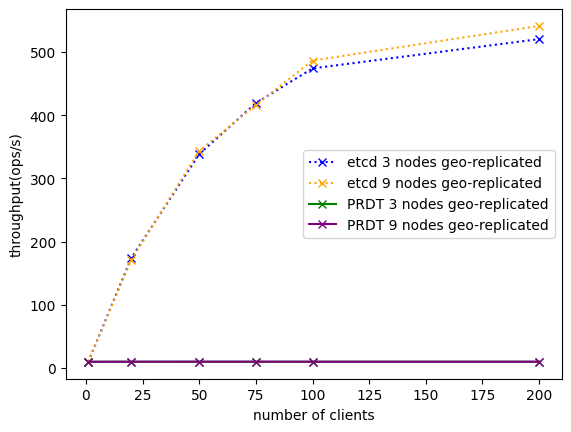

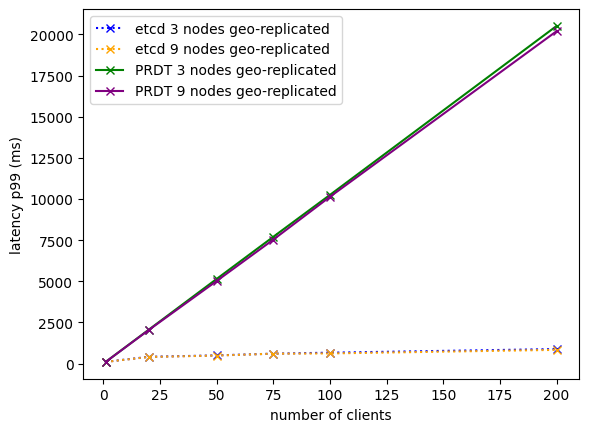

In [9]:
plot_dist_through()
plot_dist_lat()